In [ ]:
# ==========================
# Mount and Extract Dataset
# ==========================
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

# Path to your dataset in Google Drive
zip_path = '/content/drive/MyDrive/alzheimer detection.v4-augmentation.folder.zip'

# Where to extract
extract_path = '/content/alzheimer_detection_v4_augmented' # Changed to a directory path

# Extract the zip file if it doesn't exist
if not os.path.exists(extract_path):
    os.makedirs(extract_path)  # Create the directory if it doesn't exist
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Dataset extracted to: {extract_path}")
else:
    print(f"✅ Dataset already extracted to: {extract_path}")


# Check if the expected data path exists and list contents
if os.path.exists(extract_path):
    print(f"✅ Data directory found at: {extract_path}")
    print("Contents:", os.listdir(extract_path))
else:
    print(f"❌ Data directory not found at: {extract_path}")
    print("Please ensure your data is extracted to this location or update the 'extract_path' variable.")

Mounted at /content/drive
✅ Dataset extracted to: /content/alzheimer_detection_v4_augmented
✅ Data directory found at: /content/alzheimer_detection_v4_augmented
Contents: ['test', 'README.dataset.txt', 'README.roboflow.txt', 'valid', 'train']


In [ ]:
# ==========================
# Import dependencies
# ==========================
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report


100%|██████████| 4/4 [00:00<00:00, 119.05it/s]
/tmp/ipython-input-1473502479.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.label, palette='Set1')


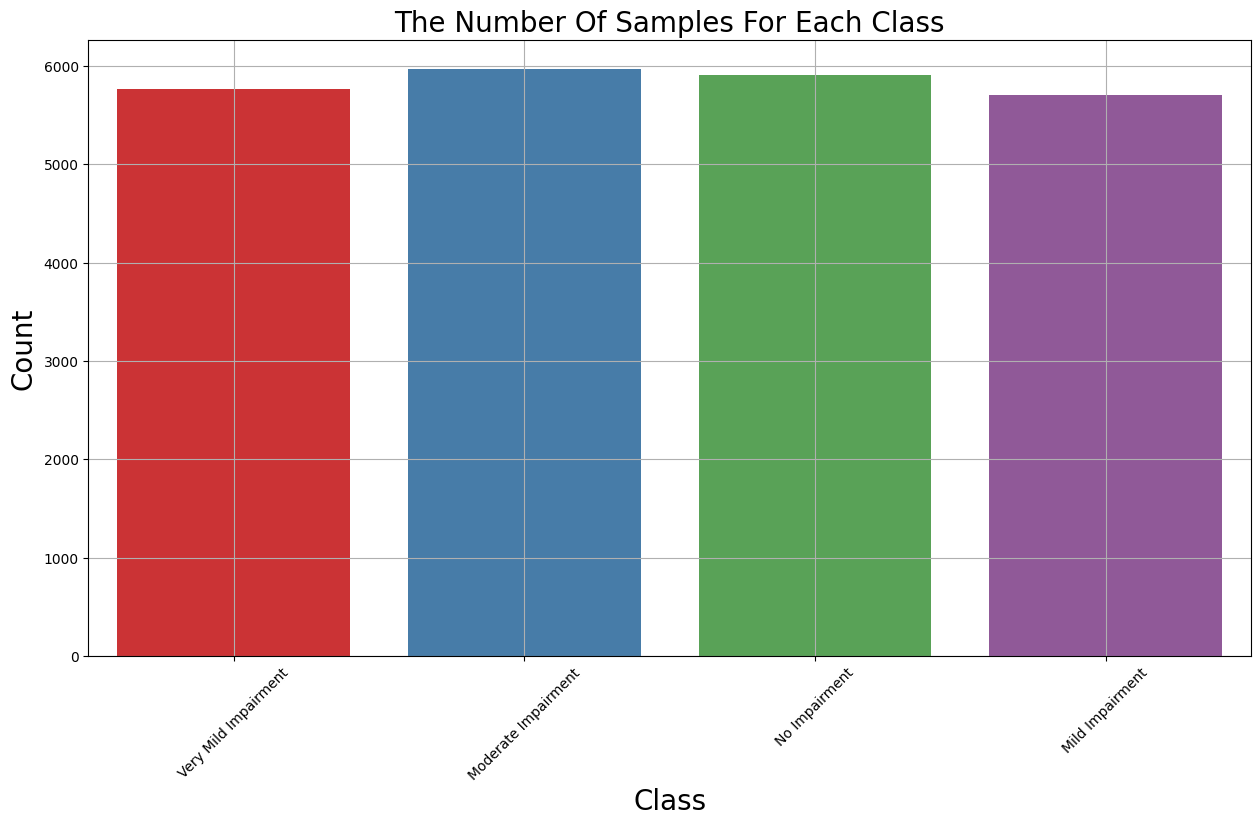

In [ ]:
# ==========================
# Prepare dataset
# ==========================
images = []
labels = []
data_path = '/content/alzheimer_detection_v4_augmented/train'

for class_folder in tqdm(os.listdir(data_path)):
    class_folder_path = os.path.join(data_path, class_folder)
    if not os.path.isdir(class_folder_path):
        continue
    for image_filename in os.listdir(class_folder_path):
        image_path = os.path.join(class_folder_path, image_filename)
        images.append(image_path)
        labels.append(class_folder)

df = pd.DataFrame({'image': images, 'label': labels})

plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ==========================
# Split dataset
# ==========================
le = LabelEncoder()
labels = le.fit_transform(df['label'])
X = df['image'].values
y = labels

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [ ]:
# ==========================
# Dataset Class
# ==========================
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

class AlzheimerMRIDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(cv2.resize(image, (224, 224)), cv2.COLOR_BGR2RGB)
        image = image.astype('float32') / 255.0
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label


In [ ]:
# ==========================
# Define Transforms and Dataloaders
# ==========================
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = AlzheimerMRIDataset(X_train, y_train, transform=transform)
val_dataset = AlzheimerMRIDataset(X_val, y_val, transform=transform)
test_dataset = AlzheimerMRIDataset(X_test, y_test, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class AlzheimerEfficientNetB0(nn.Module):
    def __init__(self, num_classes=4):
        super(AlzheimerEfficientNetB0, self).__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return torch.softmax(self.model(x), dim=1)


In [ ]:
# ==========================
# Training Setup
# ==========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlzheimerEfficientNetB0(num_classes=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
epochs = 20



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Define EfficientNet-B0
class AlzheimerEfficientNetB0(nn.Module):
    def __init__(self, num_classes=4):
        super(AlzheimerEfficientNetB0, self).__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return torch.softmax(self.model(x), dim=1)


# Set up device, model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlzheimerEfficientNetB0(num_classes=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
epochs = 20

# ==========================
# Training Loop (No Early Stopping)
# ==========================
for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0

    for images, labels in trainloader:
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.max(outputs, 1)[1]
        train_acc += torch.sum(preds == labels.data)

    train_loss /= len(trainloader.dataset)
    train_acc = float(train_acc) / len(trainloader.dataset)

    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device, dtype=torch.float)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = torch.max(outputs, 1)[1]
            val_acc += torch.sum(preds == labels.data)

    val_loss /= len(valloader.dataset)
    val_acc = float(val_acc) / len(valloader.dataset)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Save model after each epoch if better validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_efficientnet_b0.pt")

print("✅ Training Finished")


Epoch 1/20 - Train Loss: 1.0231, Acc: 0.7153 | Val Loss: 0.9620, Acc: 0.7793
Epoch 2/20 - Train Loss: 0.9625, Acc: 0.7758 | Val Loss: 0.9296, Acc: 0.8076
Epoch 3/20 - Train Loss: 0.9472, Acc: 0.7925 | Val Loss: 0.9595, Acc: 0.7790
Epoch 4/20 - Train Loss: 0.9161, Acc: 0.8252 | Val Loss: 0.8851, Acc: 0.8567
Epoch 5/20 - Train Loss: 0.9129, Acc: 0.8284 | Val Loss: 0.8905, Acc: 0.8513
Epoch 6/20 - Train Loss: 0.8932, Acc: 0.8485 | Val Loss: 0.8911, Acc: 0.8484
Epoch 7/20 - Train Loss: 0.8895, Acc: 0.8519 | Val Loss: 0.8911, Acc: 0.8507
Epoch 8/20 - Train Loss: 0.8750, Acc: 0.8662 | Val Loss: 0.9047, Acc: 0.8353
Epoch 9/20 - Train Loss: 0.8641, Acc: 0.8777 | Val Loss: 0.8689, Acc: 0.8727
Epoch 10/20 - Train Loss: 0.8578, Acc: 0.8843 | Val Loss: 0.8740, Acc: 0.8681
Epoch 11/20 - Train Loss: 0.8555, Acc: 0.8860 | Val Loss: 0.8712, Acc: 0.8707
Epoch 12/20 - Train Loss: 0.8372, Acc: 0.9048 | Val Loss: 0.8543, Acc: 0.8878
Epoch 13/20 - Train Loss: 0.8323, Acc: 0.9106 | Val Loss: 0.8392, Acc: 0.

Confusion Matrix:
 [[757   0  46  54]
 [  0 894   0   1]
 [ 17   0 807  63]
 [ 35   1 107 722]]


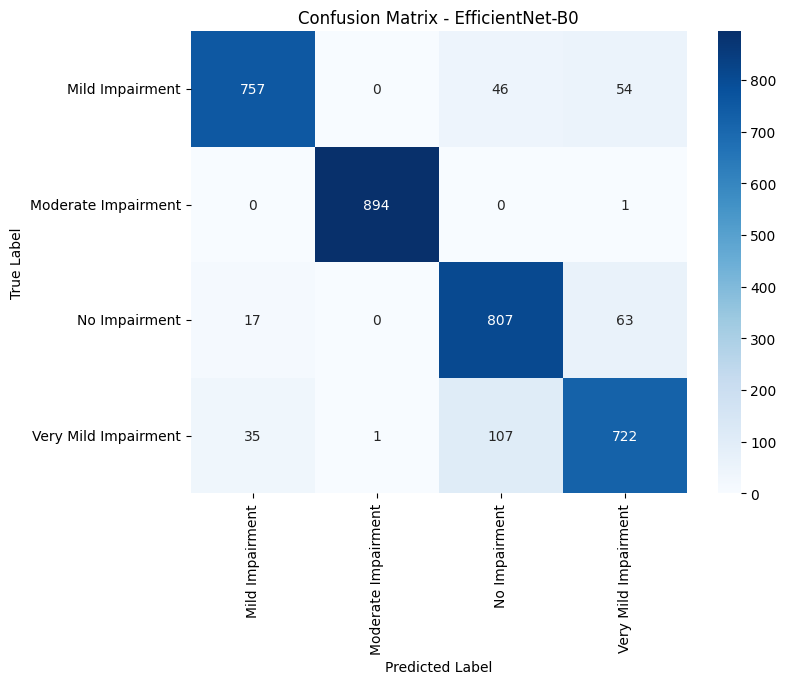

Classification Report:
                       precision    recall  f1-score   support

     Mild Impairment       0.94      0.88      0.91       857
 Moderate Impairment       1.00      1.00      1.00       895
       No Impairment       0.84      0.91      0.87       887
Very Mild Impairment       0.86      0.83      0.85       865

            accuracy                           0.91      3504
           macro avg       0.91      0.91      0.91      3504
        weighted avg       0.91      0.91      0.91      3504

Overall Accuracy: 0.9075
Balanced Accuracy: 0.9067

Per-Class Metrics:
Mild Impairment -> Precision: 0.9357, Recall: 0.8833, Specificity: 0.9804, F1: 0.9088
Moderate Impairment -> Precision: 0.9989, Recall: 0.9989, Specificity: 0.9996, F1: 0.9989
No Impairment -> Precision: 0.8406, Recall: 0.9098, Specificity: 0.9415, F1: 0.8738
Very Mild Impairment -> Precision: 0.8595, Recall: 0.8347, Specificity: 0.9553, F1: 0.8469


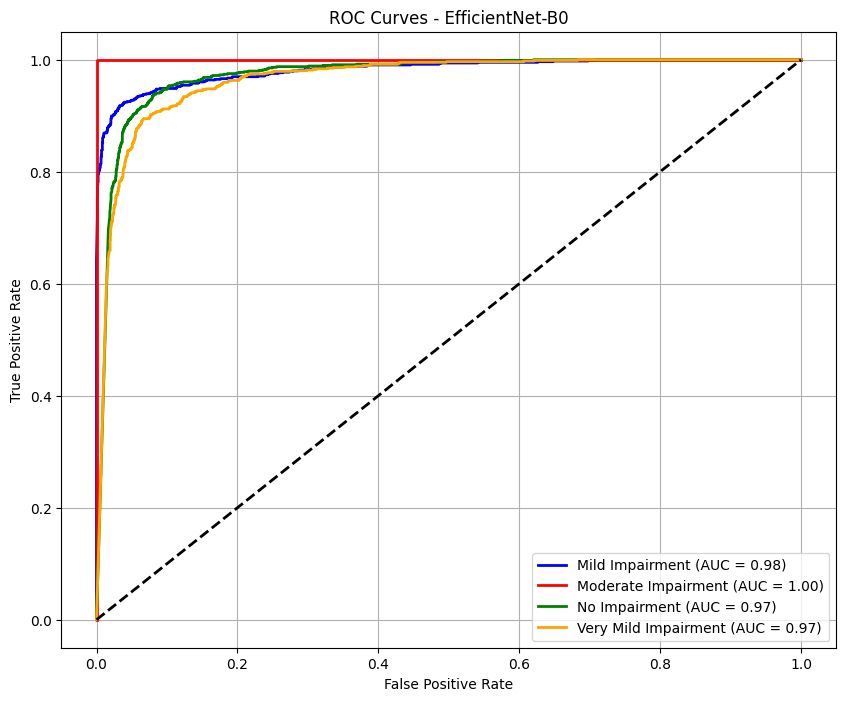


Class-wise Metrics:

Mild Impairment: TPR=0.8833, FPR=0.0196, TNR=0.9804, FNR=0.1167, ROC AUC=0.9817

Moderate Impairment: TPR=0.9989, FPR=0.0004, TNR=0.9996, FNR=0.0011, ROC AUC=0.9989

No Impairment: TPR=0.9098, FPR=0.0585, TNR=0.9415, FNR=0.0902, ROC AUC=0.9729

Very Mild Impairment: TPR=0.8347, FPR=0.0447, TNR=0.9553, FNR=0.1653, ROC AUC=0.9658


In [ ]:
# Load best EfficientNet-B0 model and evaluate
model.load_state_dict(torch.load('best_efficientnet_b0.pt'))
model.eval()

preds, true_labels, probs = [], [], []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device)
        outputs = model(images)
        probabilities = outputs.cpu().numpy()
        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        probs.extend(probabilities)

true_labels = np.array(true_labels)
preds = np.array(preds)
probs = np.array(probs)

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(true_labels, preds, target_names=le.classes_))

# Accuracy metrics
acc = accuracy_score(true_labels, preds)
bal_acc = balanced_accuracy_score(true_labels, preds)
print("Overall Accuracy:", round(acc, 4))
print("Balanced Accuracy:", round(bal_acc, 4))

# Per-class Precision, Recall, F1, Specificity
precision, recall, f1_score, support = precision_recall_fscore_support(true_labels, preds, average=None)
print("\nPer-Class Metrics:")
for i, class_name in enumerate(le.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    print(f"{class_name} -> Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, Specificity: {specificity:.4f}, F1: {f1_score[i]:.4f}")

# ROC-AUC for each class
n_classes = len(le.classes_)
y_true_bin = label_binarize(true_labels, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - EfficientNet-B0')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Class-wise sensitivity/specificity
print("\nClass-wise Metrics:")
for i in range(n_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
    FNR = FN / (TP + FN) if (TP + FN) > 0 else 0
    print(f"\n{le.classes_[i]}: TPR={TPR:.4f}, FPR={FPR:.4f}, TNR={TNR:.4f}, FNR={FNR:.4f}, ROC AUC={roc_auc[i]:.4f}")
